<a href="https://colab.research.google.com/github/Marcin19721205/Timeseries_Data_Processing_Basic/blob/main/LSTM_Stock_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install TensorFlow
# !pip install -q tensorflow-gpu==2.0.0-beta1

try:
  %tensorflow_version 2.x  # Colab only.
except Exception:
  pass

import tensorflow as tf
print(tf.__version__)

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.
2.19.0


In [2]:
# More imports
from tensorflow.keras.layers import Input, LSTM, GRU, SimpleRNN, Dense, GlobalMaxPool1D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import SGD, Adam

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [3]:
# yes, you can read dataframes from URLs!
df = pd.read_csv('https://raw.githubusercontent.com/lazyprogrammer/machine_learning_examples/master/tf2.0/sbux.csv')

In [4]:
df.head()

,date,open,high,low,close,volume,Name
0,2013-02-08,27.920,28.325,27.920,28.185,7146296,SBUX
1,2013-02-11,28.260,28.260,27.930,28.070,5457354,SBUX
2,2013-02-12,28.000,28.275,27.975,28.130,8665592,SBUX
3,2013-02-13,28.230,28.230,27.750,27.915,7022056,SBUX
4,2013-02-14,27.765,27.905,27.675,27.775,8899188,SBUX


In [10]:
# Start by doing the WRONG thing - trying to predict the price itself
series = df['close'].values.reshape(-1, 1)  # wyciąga kolumnę 'close' z DataFrame, bierze surowe wartości (NumPy) i robi z tego wektor kolumnowy o kształcie (N, 1) zamiast (N,)


In [11]:
series

array([[28.185],
       [28.07 ],
       [28.13 ],
       ...,
       [54.69 ],
       [55.61 ],
       [54.46 ]])

In [12]:
# Normalize the data  # normalizacja/standaryzacja danych (średnia=0, odchylenie=1) pod model/uczenie
# Note: I didn't think about where the true boundary is, this is just approx.  # granica train/test jest ustawiona “na oko” (tu: połowa danych), więc może być arbitralna

scaler = StandardScaler()  # tworzy obiekt standaryzacji: (x - mean) / std
scaler.fit(series[:len(series) // 2])  # liczy mean i std TYLKO na pierwszej połowie (traktowanej jako train) -> ogranicza data leakage
series = scaler.transform(series).flatten()  # stosuje tę samą skalę do CAŁEJ serii i spłaszcza z (N,1) do (N,) (żeby łatwiej robić okna/operacje 1D)


In [13]:
### build the dataset  # budowa zbioru danych (okna czasowe -> supervised learning)
# let's see if we can use T past values to predict the next value  # sprawdzamy, czy z T próbek przeszłych da się przewidzieć kolejną próbkę

T = 10  # długość okna wejściowego (ile przeszłych próbek używamy)
D = 1  # liczba cech na krok czasowy (tu 1: tylko jedna seria)
X = []  # lista na wejścia (okna długości T)
Y = []  # lista na etykiety (następna wartość po oknie)
for t in range(len(series) - T):  # przesuwamy okno po całej serii tak, by zawsze istniał punkt t+T jako target
  x = series[t:t+T]  # wycina okno: wartości od t do t+T-1 (T sztuk)
  X.append(x)  # dodaje okno do zbioru wejść
  y = series[t+T]  # target: wartość bezpośrednio po oknie (krok do przodu)
  Y.append(y)  # dodaje target do zbioru etykiet

X = np.array(X).reshape(-1, T, 1)  # konwersja do NumPy i wymuszenie kształtu (N, T, D) = (liczba_okien, długość_okna, cechy)
Y = np.array(Y)  # konwersja etykiet do NumPy (kształt (N,))
N = len(X)  # liczba próbek (okien) w zbiorze
print("X.shape", X.shape, "Y.shape", Y.shape)  # szybka kontrola: czy wymiary się zgadzają


X.shape (1249, 10, 1) Y.shape (1249,)


In [14]:
X

array([[[-1.62500489],
        [-1.64174953],
        [-1.6330132 ],
        ...,
        [-1.84778139],
        [-1.84486928],
        [-1.78517101]],

       [[-1.64174953],
        [-1.6330132 ],
        [-1.66431839],
        ...,
        [-1.84486928],
        [-1.78517101],
        [-1.85506167]],

       [[-1.6330132 ],
        [-1.66431839],
        [-1.68470317],
        ...,
        [-1.78517101],
        [-1.85506167],
        [-1.84996548]],

       ...,

       [[ 3.21273974],
        [ 3.2535093 ],
        [ 3.12828852],
        ...,
        [ 2.54295418],
        [ 2.42501368],
        [ 2.3915244 ]],

       [[ 3.2535093 ],
        [ 3.12828852],
        [ 3.08751896],
        ...,
        [ 2.42501368],
        [ 2.3915244 ],
        [ 2.2342704 ]],

       [[ 3.12828852],
        [ 3.08751896],
        [ 2.71476873],
        ...,
        [ 2.3915244 ],
        [ 2.2342704 ],
        [ 2.36822751]]])

In [15]:
Y

array([-1.85506167, -1.84996548, -1.75604989, ...,  2.2342704 ,
        2.36822751,  2.20078112])

In [16]:
### try autoregressive RNN model  # próba modelu sekwencyjnego (RNN/LSTM) do predykcji następnej próbki z okna T

i = Input(shape=(T, 1))  # wejście: sekwencja długości T, 1 cecha na krok (kształt (T,D))
x = LSTM(5)(i)  # warstwa LSTM z 5 jednostkami: kompresuje całą sekwencję do jednego wektora (ostatni stan ukryty)
x = Dense(1)(x)  # warstwa liniowa: mapuje wektor LSTM -> jedna liczba (predykcja następnej wartości)
model = Model(i, x)  # składa model w API funkcyjnym: wejście i -> wyjście x

model.summary()

model.compile(  # konfiguracja uczenia
  loss='mse',  # funkcja straty: średni błąd kwadratowy (typowe dla regresji)
  optimizer=Adam(learning_rate=0.1),  # Adam z bardzo dużym LR=0.1 (może szybko uczyć, ale też łatwo rozjechać trening)
)

# train the RNN  # trening modelu na danych sekwencyjnych
r = model.fit(  # start uczenia
  X[:-N//2], Y[:-N//2],  # train: pierwsza połowa próbek (split czasowy, bez mieszania)
  epochs=80,  # liczba epok uczenia
  validation_data=(X[-N//2:], Y[-N//2:]),  # walidacja: druga połowa próbek (sprawdzenie generalizacji w czasie)
)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 5)              │           140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 146 (584.00 B)

 Trainable params: 146 (584.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.2959 - val_loss: 0.3449
Epoch 2/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0261 - val_loss: 0.0474
Epoch 3/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0078 - val_loss: 0.0291
Epoch 4/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0062 - val_loss: 0.0319
Epoch 5/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0066 - val_loss: 0.0382
Epoch 6/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0072 - val_loss: 0.0346
Epoch 7/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0063 - val_loss: 0.0346
Epoch 8/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0072 - val_loss: 0.0290
Epoch 9/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0049 - val_loss: 0.0477
Epoch 10/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0067 - val_loss: 0.0340
Epoch 11/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0081 - val_loss: 0.0302
Epoch 12/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0072

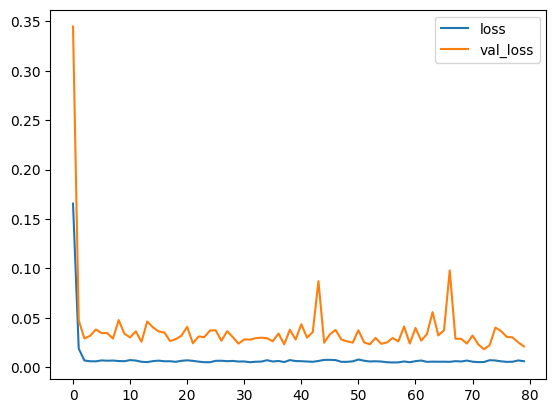

In [17]:
# Plot loss per iteration
import matplotlib.pyplot as plt
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

#it's tricky ;)

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
(1249, 1)


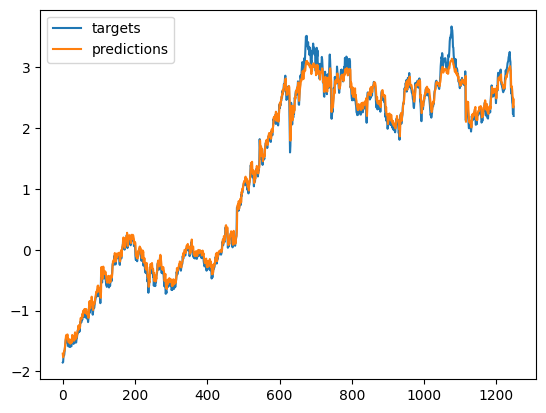

In [18]:
# One-step forecast using true targets  # predykcja "one-step ahead": każde okno X budowane jest z prawdziwych danych (bez karmienia własną predykcją)
outputs = model.predict(X)  # model przewiduje wartości dla wszystkich okien wejściowych X (wynik ma zwykle kształt (N,1))
print(outputs.shape)  # kontrola wymiaru wyjścia (np. (N, 1))
predictions = outputs[:,0]  # spłaszcza z (N,1) do (N,) wybierając jedyną kolumnę predykcji

plt.plot(Y, label='targets')  # rysuje prawdziwe wartości docelowe (następna próbka po każdym oknie)
plt.plot(predictions, label='predictions')  # rysuje predykcje modelu dla tych samych próbek
plt.legend()  # dodaje legendę, żeby wiadomo co jest czym
plt.show()  # wyświetla wykres


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━

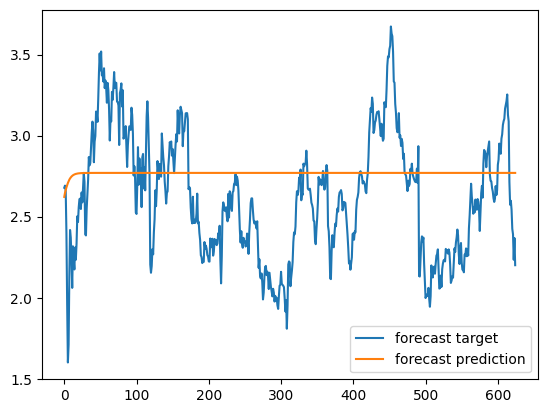

In [19]:
# Multi-step forecast  # prognoza wielokrokowa: od pewnego momentu model karmi się własnymi predykcjami (rolling forecast)
validation_target = Y[-N//2:]  # "prawdziwe" targety dla części walidacyjnej (druga połowa próbek)
validation_predictions = []  # tu będziemy zbierać prognozy wielokrokowe

# first validation input  # startowe okno wejściowe dla prognozy (pierwsze okno z walidacji)
last_x = X[-N//2] # 1-D array of length T  # ostatnie_x to okno długości T (w praktyce ma kształt (T,1), mimo komentarza)

while len(validation_predictions) < len(validation_target):  # iterujemy tyle kroków, ile jest targetów do przewidzenia
  p = model.predict(last_x.reshape(1, T, 1))[0,0] # 1x1 array -> scalar  # predykcja 1 kroku do przodu; reshape dodaje wymiar batch=1

  # update the predictions list  # dopisuje bieżącą prognozę do listy wyników
  validation_predictions.append(p)

  # make the new input  # buduje kolejne okno wejściowe: przesuwa okno w lewo i dokleja na końcu świeżą predykcję
  last_x = np.roll(last_x, -1)  # przesuwa elementy o 1 w lewo (najstarsza próbka wypada)
  last_x[-1] = p  # wstawia predykcję jako najnowszą próbkę w oknie (tu właśnie pojawia się "feedback" z modelu)

plt.plot(validation_target, label='forecast target')  # wykres prawdziwych wartości w horyzoncie prognozy
plt.plot(validation_predictions, label='forecast prediction')  # wykres prognozy wielokrokowej (z autokarmieniem)
plt.legend()  # legenda (bez plt.show() - w notebooku często i tak się wyświetli, ale w skrypcie by brakowało)


In [20]:
# calculate returns by first shifting the data  # przygotowanie do liczenia stóp zwrotu (returns) przez dodanie poprzedniej ceny
df['PrevClose'] = df['close'].shift(1) # move everything up 1  # przesuwa kolumnę 'close' o 1 w dół (czyli dla wiersza t wpisuje close z t-1); pierwszy wiersz dostanie NaN

# so now it's like  # po tym przesunięciu mamy w każdej linii parę: (close_t, close_{t-1})
# close / prev close  # typowy wzór na return względny: close_t / close_{t-1} (albo minus 1, jeśli chcesz procentową zmianę)
# x[2] x[1]  # dla indeksu 2: bieżąca cena x[2], poprzednia x[1]
# x[3] x[2]  # dla indeksu 3: bieżąca x[3], poprzednia x[2]
# x[4] x[3]  # itd.
# ...
# x[t] x[t-1]  # ogólnie: wiersz t porównuje close_t do close_{t-1}


In [21]:
df.head()

,date,open,high,low,close,volume,Name,PrevClose
0,2013-02-08,27.920,28.325,27.920,28.185,7146296,SBUX,NaN
1,2013-02-11,28.260,28.260,27.930,28.070,5457354,SBUX,28.185
2,2013-02-12,28.000,28.275,27.975,28.130,8665592,SBUX,28.070
3,2013-02-13,28.230,28.230,27.750,27.915,7022056,SBUX,28.130
4,2013-02-14,27.765,27.905,27.675,27.775,8899188,SBUX,27.915


In [22]:
# then the return is  # teraz liczona jest stopa zwrotu (zmiana względna) między kolejnymi cenami
# (x[t] - x[t-1]) / x[t-1]  # definicja return: różnica podzielona przez poprzednią wartość (czyli procentowo, ale w ułamku)
df['Return'] = (df['close'] - df['PrevClose']) / df['PrevClose']  # liczy return dla każdego wiersza; pierwszy wiersz będzie NaN (bo PrevClose=NaN)


In [25]:
df.head()

,date,open,high,low,close,volume,Name,PrevClose,Return
0,2013-02-08,27.920,28.325,27.920,28.185,7146296,SBUX,NaN,NaN
1,2013-02-11,28.260,28.260,27.930,28.070,5457354,SBUX,28.185,-0.004080
2,2013-02-12,28.000,28.275,27.975,28.130,8665592,SBUX,28.070,0.002138
3,2013-02-13,28.230,28.230,27.750,27.915,7022056,SBUX,28.130,-0.007643
4,2013-02-14,27.765,27.905,27.675,27.775,8899188,SBUX,27.915,-0.005015


<Axes: >

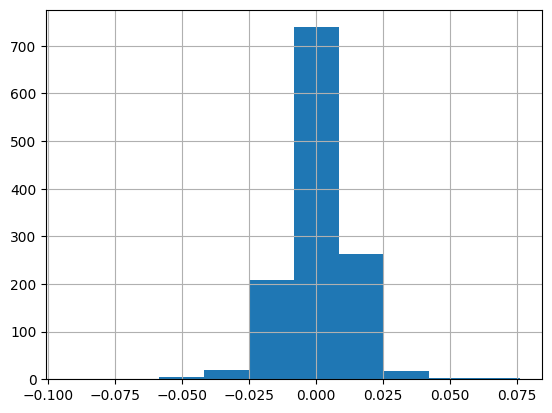

In [26]:
# Now let's try an LSTM to predict returns
df['Return'].hist()

In [27]:
series = df['Return'].values[1:].reshape(-1, 1)

# Normalize the data
# Note: I didn't think about where the true boundary is, this is just approx.
scaler = StandardScaler()
scaler.fit(series[:len(series) // 2])
series = scaler.transform(series).flatten()

In [28]:
### build the dataset
# let's see if we can use T past values to predict the next value
T = 10
D = 1
X = []
Y = []
for t in range(len(series) - T):
  x = series[t:t+T]
  X.append(x)
  y = series[t+T]
  Y.append(y)

X = np.array(X).reshape(-1, T, 1) # Now the data should be N x T x D
Y = np.array(Y)
N = len(X)
print("X.shape", X.shape, "Y.shape", Y.shape)

X.shape (1248, 10, 1) Y.shape (1248,)


In [30]:
### try autoregressive RNN model
i = Input(shape=(T, 1))
x = LSTM(5)(i)
x = Dense(1)(x)
model = Model(i, x)
model.compile(
  loss='mse',
  optimizer=Adam(learning_rate=0.01),
)

# train the RNN
r = model.fit(
  X[:-N//2], Y[:-N//2],
  epochs=80,
  validation_data=(X[-N//2:], Y[-N//2:]),
)

Epoch 1/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.9720 - val_loss: 1.1612
Epoch 2/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.2256 - val_loss: 1.1506
Epoch 3/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.9491 - val_loss: 1.1528
Epoch 4/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.9662 - val_loss: 1.1523
Epoch 5/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.9681 - val_loss: 1.1397
Epoch 6/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.9487 - val_loss: 1.1650
Epoch 7/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.0474 - val_loss: 1.1603
Epoch 8/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.9859 - val_loss: 1.1453
Epoch 9/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.0726 - val_loss: 1.1519
Epoch 10/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.1149 - val_loss: 1.1530
Epoch 11/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.9783 - val_loss: 1.1496
Epoch 12/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.8

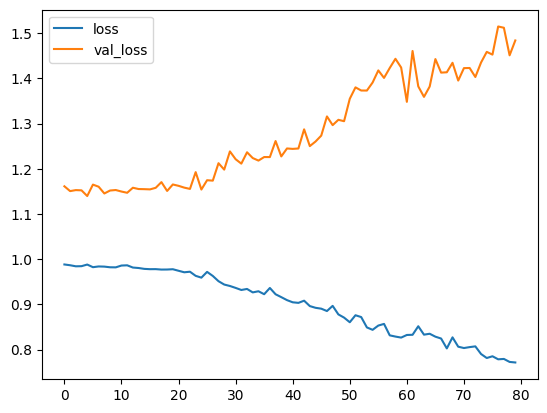

In [31]:
# Plot loss per iteration
import matplotlib.pyplot as plt
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
(1248, 1)


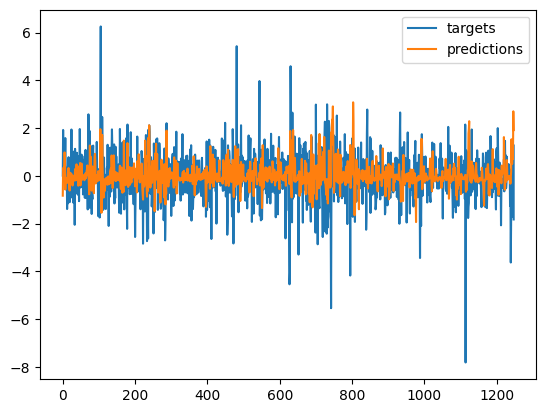

In [32]:
# One-step forecast using true targets
outputs = model.predict(X)
print(outputs.shape)
predictions = outputs[:,0]

plt.plot(Y, label='targets')
plt.plot(predictions, label='predictions')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 556ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━

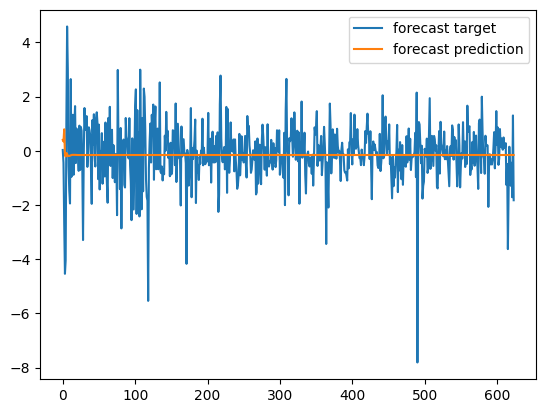

In [33]:
# Multi-step forecast
validation_target = Y[-N//2:]
validation_predictions = []

# first validation input
last_x = X[-N//2] # 1-D array of length T

while len(validation_predictions) < len(validation_target):
  p = model.predict(last_x.reshape(1, T, 1))[0,0] # 1x1 array -> scalar

  # update the predictions list
  validation_predictions.append(p)

  # make the new input
  last_x = np.roll(last_x, -1)
  last_x[-1] = p

plt.plot(validation_target, label='forecast target')
plt.plot(validation_predictions, label='forecast prediction')
plt.legend()

#Correct Model

In [34]:
# Now turn the full data into numpy arrays

# Not yet in the final "X" format!
input_data = df[['open', 'high', 'low', 'close', 'volume']].values
targets = df['Return'].values

In [35]:
# Now make the actual data which will go into the neural network
T = 10 # the number of time steps to look at to make a prediction for the next day
D = input_data.shape[1] #number of column in input data
N = len(input_data) - T # (e.g. if T=10 and you have 11 data points then you'd only have 1 sample)

In [36]:
# normalize the inputs
Ntrain = len(input_data) * 2 // 3
scaler = StandardScaler()
scaler.fit(input_data[:Ntrain + T - 1])
input_data = scaler.transform(input_data)

In [37]:
# Setup X_train and Y_train
X_train = np.zeros((Ntrain, T, D))
Y_train = np.zeros(Ntrain)

for t in range(Ntrain):
  X_train[t, :, :] = input_data[t:t+T]
  Y_train[t] = (targets[t+T] > 0)

In [38]:
# Setup X_test and Y_test
X_test = np.zeros((N - Ntrain, T, D))
Y_test = np.zeros(N - Ntrain)

for u in range(N - Ntrain):
  # u counts from 0...(N - Ntrain)
  # t counts from Ntrain...N
  t = u + Ntrain
  X_test[u, :, :] = input_data[t:t+T]
  Y_test[u] = (targets[t+T] > 0)

In [40]:
# make the RNN
i = Input(shape=(T, D))
x = LSTM(50)(i)
x = Dense(1, activation='sigmoid')(x)
model = Model(i, x)
model.compile(
  loss='binary_crossentropy',
  optimizer=Adam(learning_rate=0.001),
  metrics=['accuracy'],
)

In [41]:
# train the RNN
r = model.fit(
  X_train, Y_train,
  batch_size=32,
  epochs=300,
  validation_data=(X_test, Y_test),
)

Epoch 1/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - accuracy: 0.4806 - loss: 0.6971 - val_accuracy: 0.5049 - val_loss: 0.6958
Epoch 2/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5251 - loss: 0.6901 - val_accuracy: 0.4732 - val_loss: 0.6975
Epoch 3/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5215 - loss: 0.6914 - val_accuracy: 0.4805 - val_loss: 0.6957
Epoch 4/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5190 - loss: 0.6923 - val_accuracy: 0.4829 - val_loss: 0.6951
Epoch 5/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5172 - loss: 0.6891 - val_accuracy: 0.4878 - val_loss: 0.6935
Epoch 6/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5331 - loss: 0.6897 - val_accuracy: 0.4927 - val_loss: 0.6946
Epoch 7/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5362 - loss: 0.6899 - val_accuracy: 0.4951 - val_loss: 0.6961
Epoch 8/300
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5252 - loss: 0.6903 - val_accuracy: 0.

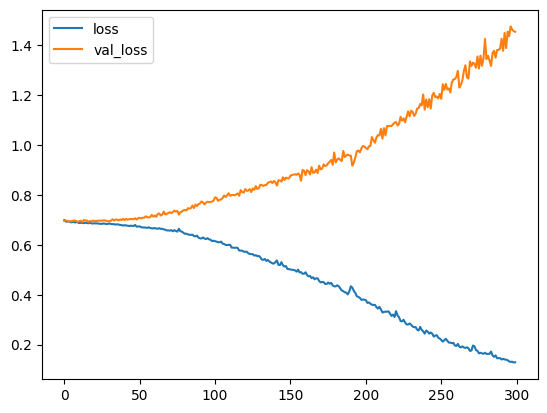

In [42]:
# plot the loss
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

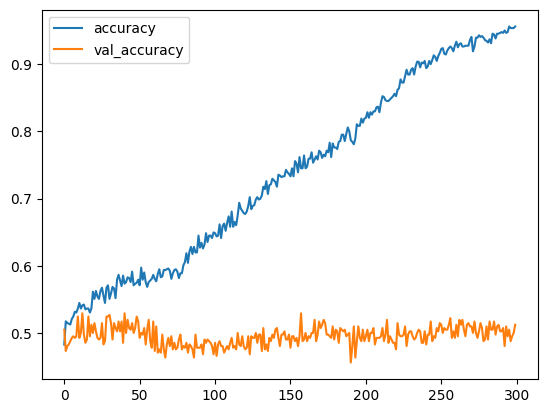

In [43]:
# Plot accuracy per iteration
plt.plot(r.history['accuracy'], label='accuracy')
plt.plot(r.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.show()